# Graph Construction

Calls `src/graphs.py` functions. Includes SAGEConv directionality verification.
No logic lives here.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
import config
from src.graphs import (
    build_correlation_graph, save_correlation_samples,
    build_sector_graph, build_granger_graph,
    build_all_sector_graphs, make_pyg_data,
    run_granger_tests, run_granger_tests_cpu, run_granger_tests_gpu,
    verify_sageconv_directionality,
)

## Sector Graph

In [2]:
import json
from collections import Counter

with open("../data/raw/tickers.json") as f:
    tickers = json.load(f)
with open("../data/raw/sector_history.json") as f:
    sector_history = json.load(f)

# Build all sector graphs and save parquet
sector_graphs = build_all_sector_graphs(tickers, sector_history, range(2015, 2026))

# Node counts per sector per year
year_sector_counts = {}
for year in [2016, 2017]:
    counts = Counter(
        sector_history.get(t, {}).get(str(year))
        for t in tickers
        if sector_history.get(t, {}).get(str(year))
    )
    year_sector_counts[year] = len(counts)
    print(f"\n{year} — {len(counts)} sectors, {sum(counts.values())} nodes")
    for sector, n in sorted(counts.items(), key=lambda x: -x[1]):
        print(f"  {sector}: {n}")

# Full-universe check: 2016 should have 10 GICS sectors, 2017 should have 11
# (Real Estate split from Financials in August 2016). Skipped for dev universe.
if len(tickers) >= 400:
    assert year_sector_counts[2016] >= 10, \
        f"Expected >=10 sectors in 2016, got {year_sector_counts[2016]}"
    assert year_sector_counts[2017] >= 11, \
        f"Expected >=11 sectors in 2017, got {year_sector_counts[2017]}"
    print("\nSector count assertions passed (full universe).")

Saved 3968 total edges across 11 years to C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\graphs\sector_edges_by_year.parquet

2016 — 9 sectors, 50 nodes
  Financial Services: 14
  Technology: 10
  Healthcare: 9
  Consumer Cyclical: 7
  Utilities: 3
  Industrials: 3
  Consumer Defensive: 2
  Energy: 1
  Basic Materials: 1

2017 — 10 sectors, 50 nodes
  Financial Services: 12
  Technology: 10
  Healthcare: 9
  Consumer Cyclical: 7
  Utilities: 3
  Industrials: 3
  Consumer Defensive: 2
  Real Estate: 2
  Energy: 1
  Basic Materials: 1


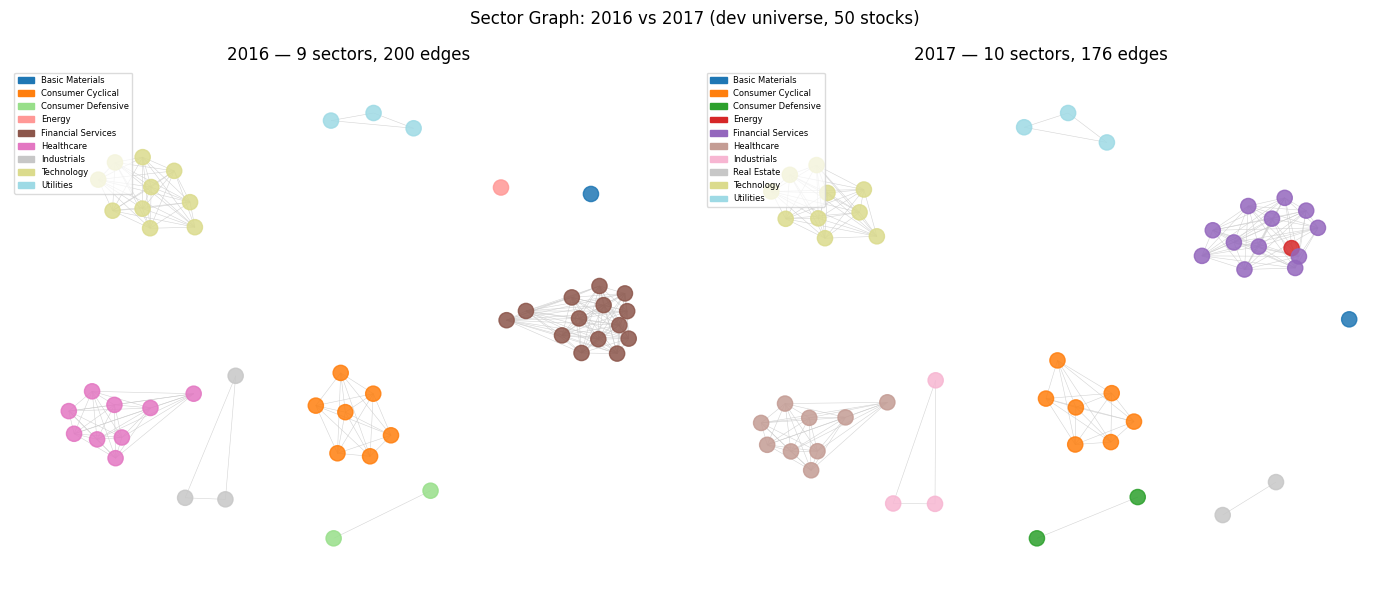

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_sector_graph(tickers, sector_graphs, sector_history, year, ax):
    edge_index = sector_graphs[year]
    G = nx.Graph()
    G.add_nodes_from(range(len(tickers)))
    src = edge_index[0].tolist()
    dst = edge_index[1].tolist()
    # Add only one direction to avoid duplicate edges in undirected nx graph
    edges = {(min(s, d), max(s, d)) for s, d in zip(src, dst)}
    G.add_edges_from(edges)

    sectors = [sector_history.get(t, {}).get(str(year), "Unknown") for t in tickers]
    unique_sectors = sorted(set(sectors))
    color_map = {s: plt.cm.tab20(i / max(len(unique_sectors) - 1, 1))
                 for i, s in enumerate(unique_sectors)}
    node_colors = [color_map[s] for s in sectors]

    pos = nx.spring_layout(G, seed=config.RANDOM_SEED, k=0.6)
    nx.draw_networkx(G, pos=pos, ax=ax, node_color=node_colors,
                     node_size=120, with_labels=False, edge_color="#cccccc",
                     width=0.4, alpha=0.85)
    legend_handles = [mpatches.Patch(color=color_map[s], label=s) for s in unique_sectors]
    ax.legend(handles=legend_handles, fontsize=6, loc="upper left", framealpha=0.7)
    ax.set_title(f"{year} — {len(unique_sectors)} sectors, {G.number_of_edges()} edges")
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_sector_graph(tickers, sector_graphs, sector_history, 2016, axes[0])
plot_sector_graph(tickers, sector_graphs, sector_history, 2017, axes[1])
plt.suptitle("Sector Graph: 2016 vs 2017 (dev universe, 50 stocks)", fontsize=12)
plt.tight_layout()
plt.show()

## Correlation Graph

In [4]:
import pandas as pd

log_returns = pd.read_parquet("../data/raw/log_returns.parquet")
print(f"log_returns shape: {log_returns.shape}")
print(f"Date range: {log_returns.index[0].date()} to {log_returns.index[-1].date()}")

log_returns shape: (2764, 50)
Date range: 2015-01-05 to 2025-12-30


In [5]:
print(f"Building correlation graphs (threshold θ={config.CORR_THRESHOLD}, "
      f"lookback={config.CORR_LOOKBACK_DAYS} days):\n")
corr_samples = save_correlation_samples(log_returns, tickers)

Building correlation graphs (threshold θ=0.5, lookback=252 days):

  calm     (2017-06-30):     92 directed edges  (   46 unique pairs)
  covid    (2020-03-13):   1724 directed edges  (  862 unique pairs)
  recent   (2023-06-30):    788 directed edges  (  394 unique pairs)


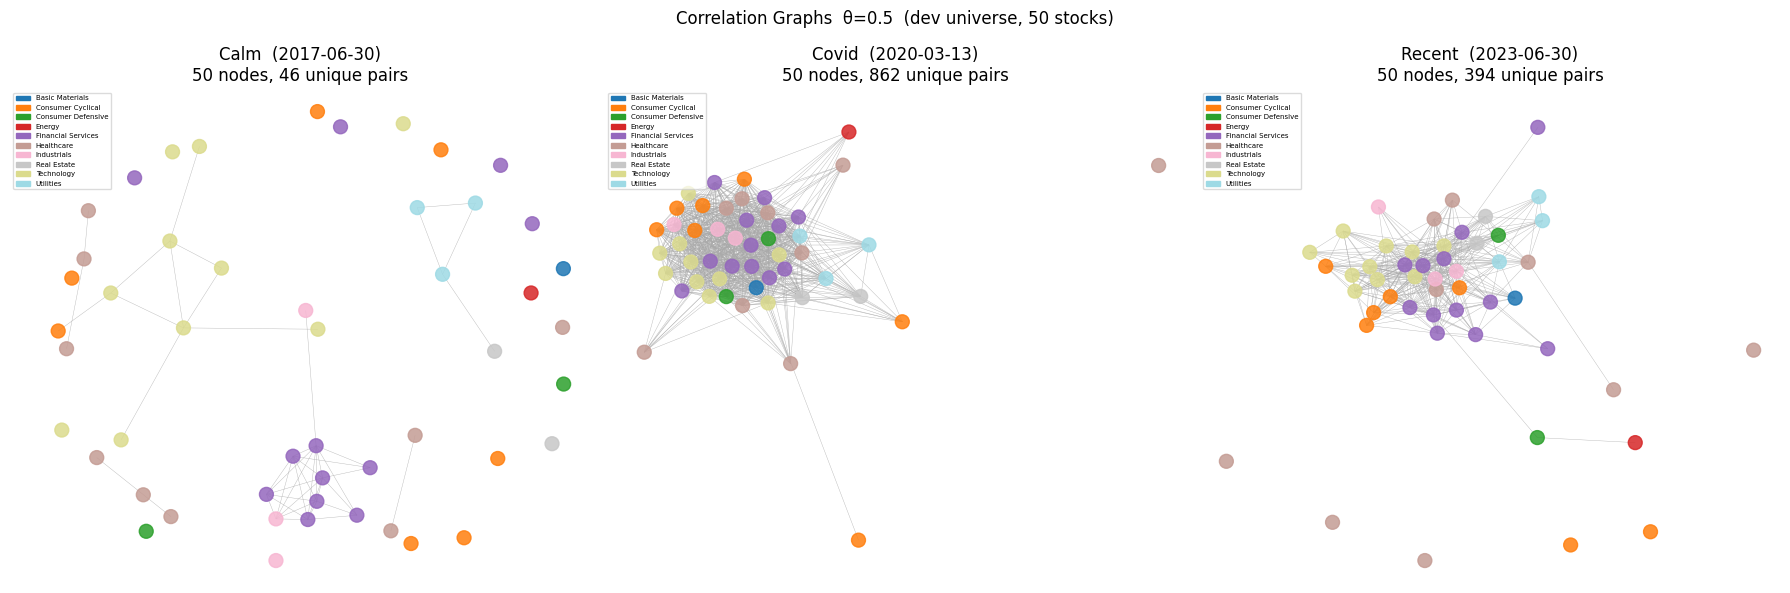

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Year used for sector coloring in each sample graph
_SAMPLE_YEARS = {"calm": 2017, "covid": 2020, "recent": 2023}

def plot_correlation_graph(edge_index, tickers, sector_history, year, ax, title):
    G = nx.Graph()
    G.add_nodes_from(range(len(tickers)))
    src = edge_index[0].tolist()
    dst = edge_index[1].tolist()
    edges = {(min(s, d), max(s, d)) for s, d in zip(src, dst)}
    G.add_edges_from(edges)

    sectors = [sector_history.get(t, {}).get(str(year), "Unknown") for t in tickers]
    unique_sectors = sorted(set(sectors))
    color_map = {s: plt.cm.tab20(i / max(len(unique_sectors) - 1, 1))
                 for i, s in enumerate(unique_sectors)}
    node_colors = [color_map[s] for s in sectors]

    pos = nx.spring_layout(G, seed=config.RANDOM_SEED, k=0.6)
    nx.draw_networkx(G, pos=pos, ax=ax, node_color=node_colors,
                     node_size=100, with_labels=False, edge_color="#aaaaaa",
                     width=0.3, alpha=0.85)
    legend_handles = [mpatches.Patch(color=color_map[s], label=s) for s in unique_sectors]
    ax.legend(handles=legend_handles, fontsize=5, loc="upper left", framealpha=0.7)
    ax.set_title(f"{title}\n{G.number_of_nodes()} nodes, {G.number_of_edges()} unique pairs")
    ax.axis("off")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for (label, date_str), ax in zip(config.CORR_SAMPLE_DATES.items(), axes):
    plot_correlation_graph(
        corr_samples[label], tickers, sector_history,
        _SAMPLE_YEARS[label], ax,
        title=f"{label.capitalize()}  ({date_str})"
    )
plt.suptitle(f"Correlation Graphs  θ={config.CORR_THRESHOLD}  (dev universe, {len(tickers)} stocks)",
             fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
calm_edges  = corr_samples["calm"].shape[1]
covid_edges = corr_samples["covid"].shape[1]
assert covid_edges > calm_edges, (
    f"Expected COVID edge count ({covid_edges}) > calm ({calm_edges})"
)
print(f"Edge count rises from calm to COVID: {calm_edges} -> {covid_edges} (confirmed)")

Edge count rises from calm to COVID: 92 -> 1724 (confirmed)


## Granger Causality Graph

Two-step workflow — keep the steps separate so you can re-run the correction without re-running the tests:

**Step 1 — Compute p-values** (`run_granger_tests`): runs the Granger F-test for all N*(N-1) ordered stock pairs over 2015-2022 training data. Saves `data/graphs/granger_pvalues.parquet`. Takes ~5-15 min on GPU (A100), ~6-12h on CPU.

**Step 2 — Build graph** (`build_granger_graph`): loads the saved p-values, applies Bonferroni correction (falls back to BH FDR if <500 edges survive), saves `data/graphs/granger_edges.parquet`, returns directed `edge_index`.

**GPU vs CPU**: `run_granger_tests` auto-detects CUDA. On Colab with A100, it calls `run_granger_tests_gpu` which batches all N-1 unrestricted OLS fits per target stock as a single GPU operation. On CPU, it calls `run_granger_tests_cpu` which uses multiprocessing with statsmodels. Both produce the same p-values within float64 precision.

### Validate: manual F-test matches statsmodels

Runs 3 pairs through both our manual OLS formula and statsmodels on CPU. Confirms p-values agree within 1e-6 before committing to the full GPU run.

In [8]:
import numpy as np
from statsmodels.tsa.stattools import grangercausalitytests
from scipy.stats import f as f_dist

train_data = log_returns.loc[:config.TRAIN_END].dropna().values.astype(np.float64)
T, N = train_data.shape
lag = config.GRANGER_LAG
T_eff = T - lag
df1 = lag
df2 = T_eff - 2 * lag - 1  # T_eff rows minus (2*lag + 1) unrestricted params

print(f"Training data: {T} days, {N} stocks, T_eff={T_eff}, df1={df1}, df2={df2}\n")

test_pairs = [(0, 1), (5, 10), (20, 30)]  # (b_idx=target, a_idx=cause)
max_err = 0.0

for b_idx, a_idx in test_pairs:
    # statsmodels: column 0 = target B, column 1 = cause A
    data_sm = np.column_stack([train_data[:, b_idx], train_data[:, a_idx]])
    res = grangercausalitytests(data_sm, maxlag=lag, verbose=False)
    F_sm   = res[lag][0]["ssr_ftest"][0]
    pval_sm = res[lag][0]["ssr_ftest"][1]

    # Manual OLS matching the GPU implementation
    y = train_data[lag:, b_idx]
    B_lags = np.column_stack([train_data[lag-1-l:T-1-l, b_idx] for l in range(lag)])
    A_lags = np.column_stack([train_data[lag-1-l:T-1-l, a_idx] for l in range(lag)])
    X_r  = np.column_stack([np.ones(T_eff), B_lags])
    X_ur = np.column_stack([np.ones(T_eff), B_lags, A_lags])
    beta_r,  _, _, _ = np.linalg.lstsq(X_r,  y, rcond=None)
    beta_ur, _, _, _ = np.linalg.lstsq(X_ur, y, rcond=None)
    RSS_r  = np.sum((y - X_r  @ beta_r)  ** 2)
    RSS_ur = np.sum((y - X_ur @ beta_ur) ** 2)
    F_man  = max(0.0, ((RSS_r - RSS_ur) / df1) / (RSS_ur / df2))
    pval_man = float(f_dist.sf(F_man, df1, df2))

    err = abs(pval_sm - pval_man)
    max_err = max(max_err, err)
    print(f"  ({tickers[b_idx]}, {tickers[a_idx]})  "
          f"statsmodels p={pval_sm:.8f}  manual p={pval_man:.8f}  diff={err:.2e}")

assert max_err < 1e-6, f"Max p-value discrepancy {max_err:.2e} exceeds 1e-6"
print(f"\nAll {len(test_pairs)} pairs match statsmodels within 1e-6. GPU formula verified.")

Training data: 2013 days, 50 stocks, T_eff=2008, df1=5, df2=1997

  (A, AAPL)  statsmodels p=0.00617798  manual p=0.00617798  diff=0.00e+00
  (ADBE, AEE)  statsmodels p=0.00000056  manual p=0.00000056  diff=5.92e-20
  (AME, AVB)  statsmodels p=0.00051139  manual p=0.00051139  diff=4.72e-17

All 3 pairs match statsmodels within 1e-6. GPU formula verified.


c:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\.venv\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


### Step 1: Compute p-values

Runs once. On GPU (A100): ~5-15 min for full universe, seconds for dev (N=50).
Saves `data/graphs/granger_pvalues.parquet` — an N×N DataFrame of p-values.

In [9]:
import time

t0 = time.time()
pval_df = run_granger_tests(log_returns, tickers)
elapsed = time.time() - t0

print(f"\nElapsed: {elapsed:.1f}s")
print(f"P-value matrix shape: {pval_df.shape}")
print(f"Min off-diagonal p-value: {pval_df.values[~np.eye(len(tickers), dtype=bool)].min():.4e}")
print(f"Fraction of pairs with p < 0.05 (uncorrected): "
      f"{(pval_df.values[~np.eye(len(tickers), dtype=bool)] < 0.05).mean():.3f}")

CUDA detected — using GPU batched OLS (run_granger_tests_gpu).
GPU Granger tests: 50 stocks, 2013 training days, lag=5
T_eff=2008, df1=5, df2=1997, device=NVIDIA GeForce RTX 3070 Laptop GPU
    50/50 target stocks done
Saved (50, 50) p-value matrix -> C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\graphs\granger_pvalues.parquet

Elapsed: 0.7s
P-value matrix shape: (50, 50)
Min off-diagonal p-value: 5.1703e-19
Fraction of pairs with p < 0.05 (uncorrected): 0.644


### Step 2: Build directed graph

Loads the saved p-values, applies Bonferroni correction, falls back to BH if <500 edges survive.
Saves `data/graphs/granger_edges.parquet`.

In [10]:
granger_edge_index, correction_used = build_granger_graph(tickers)

n_edges = granger_edge_index.shape[1]
n_possible = len(tickers) * (len(tickers) - 1)
density = n_edges / n_possible

print(f"Correction method : {correction_used}")
print(f"Directed edges    : {n_edges:,} / {n_possible:,} possible")
print(f"Graph density     : {density:.4f}")
print(f"edge_index shape  : {tuple(granger_edge_index.shape)}")

Bonferroni yielded 379 edges (< GRANGER_MIN_EDGES=500). Falling back to Benjamini-Hochberg FDR.
Correction: bh  |  Edges: 1,443 / 2,450 pairs
Saved 1,443 directed edges -> C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\graphs\granger_edges.parquet
Correction method : bh
Directed edges    : 1,443 / 2,450 possible
Graph density     : 0.5890
edge_index shape  : (2, 1443)


### In/out-degree distribution

Out-degree  mean=28.9  max=47  (AEE — highest out-degree)
In-degree   mean=28.9  max=47  (AEE — highest in-degree)


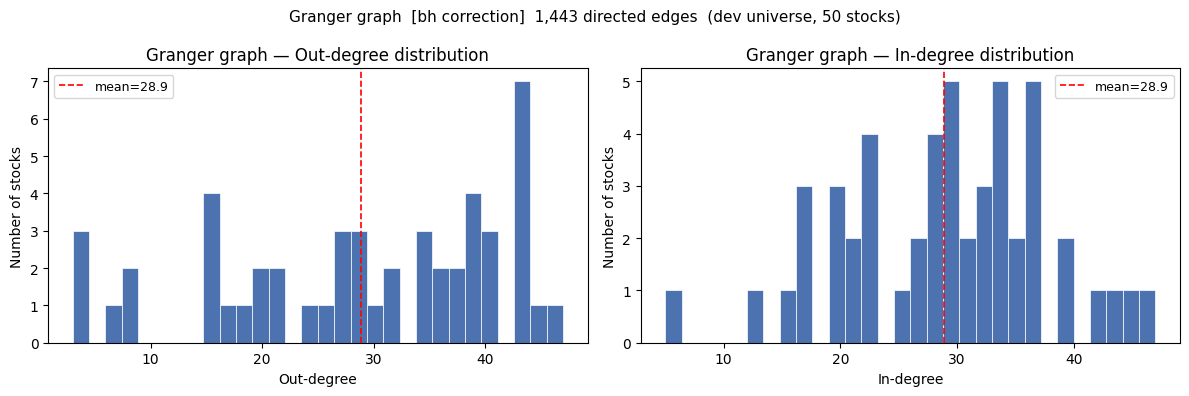

In [11]:
import matplotlib.pyplot as plt
import numpy as np

src_nodes = granger_edge_index[0].numpy()
dst_nodes = granger_edge_index[1].numpy()
N = len(tickers)

out_degree = np.bincount(src_nodes, minlength=N)
in_degree  = np.bincount(dst_nodes, minlength=N)

print(f"Out-degree  mean={out_degree.mean():.1f}  max={out_degree.max()}  "
      f"({tickers[out_degree.argmax()]} — highest out-degree)")
print(f"In-degree   mean={in_degree.mean():.1f}  max={in_degree.max()}  "
      f"({tickers[in_degree.argmax()]} — highest in-degree)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, degree, label in zip(axes, [out_degree, in_degree], ["Out-degree", "In-degree"]):
    ax.hist(degree, bins=30, color="#4c72b0", edgecolor="white", linewidth=0.5)
    ax.axvline(degree.mean(), color="red", linestyle="--", linewidth=1.2,
               label=f"mean={degree.mean():.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Number of stocks")
    ax.set_title(f"Granger graph — {label} distribution")
    ax.legend(fontsize=9)

plt.suptitle(
    f"Granger graph  [{correction_used} correction]  "
    f"{n_edges:,} directed edges  (dev universe, {N} stocks)",
    fontsize=11
)
plt.tight_layout()
plt.show()

### Directed graph — sector-colored nodes

Arrows show Granger causality direction (A → B means A's past returns predict B's). Nodes colored by 2022 sector assignment (end of training period). Edge alpha is low to keep the plot readable at high density.

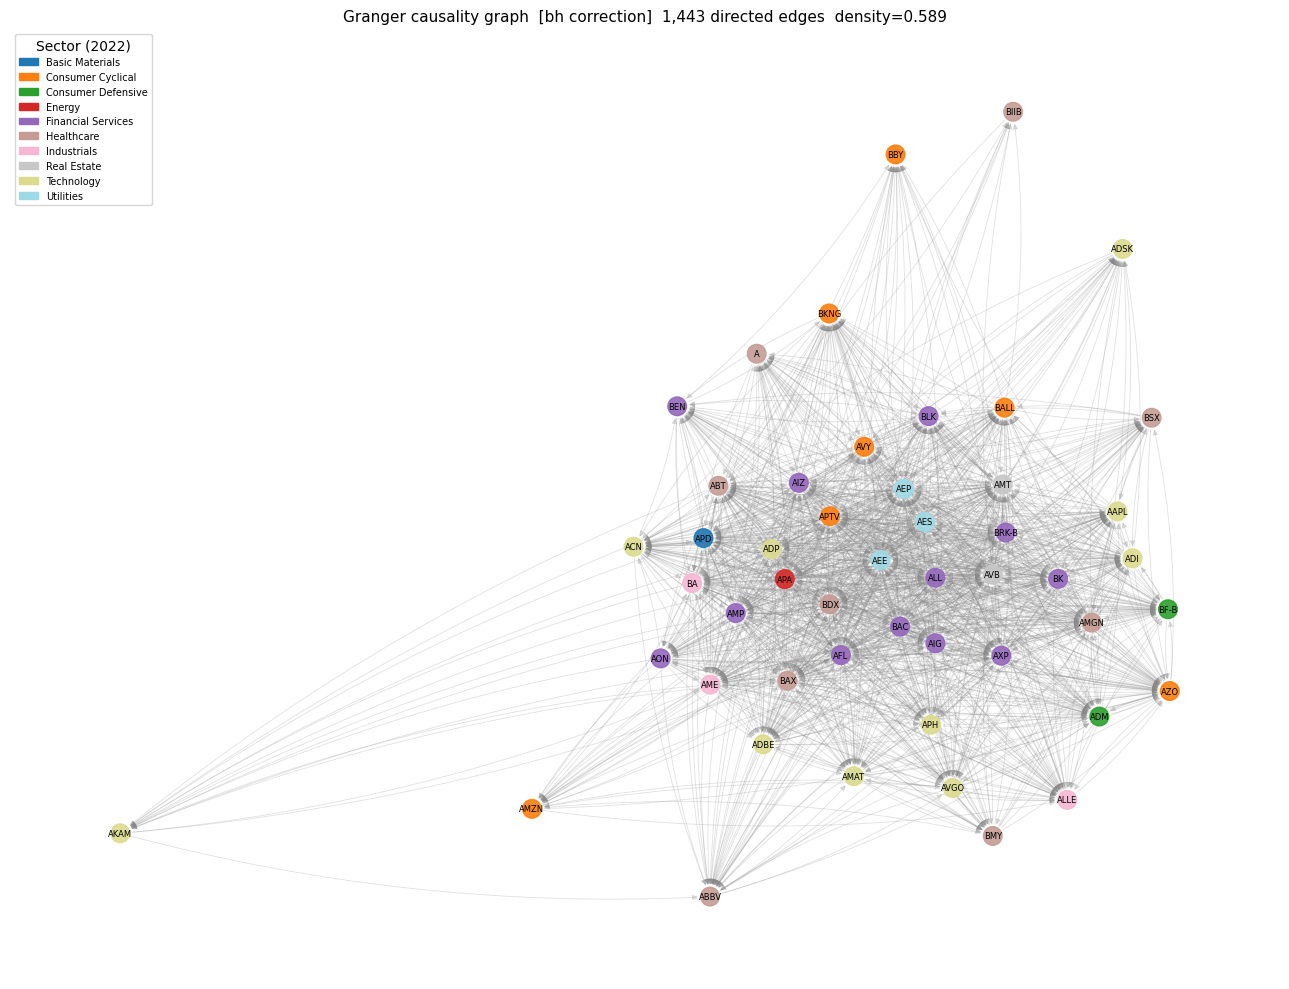

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

_GRANGER_SECTOR_YEAR = 2022  # end of training period

G = nx.DiGraph()
G.add_nodes_from(range(len(tickers)))
G.add_edges_from(zip(granger_edge_index[0].tolist(), granger_edge_index[1].tolist()))

sectors_2022 = [sector_history.get(t, {}).get(str(_GRANGER_SECTOR_YEAR), "Unknown")
                for t in tickers]
unique_sectors = sorted(set(sectors_2022))
color_map = {s: plt.cm.tab20(i / max(len(unique_sectors) - 1, 1))
             for i, s in enumerate(unique_sectors)}
node_colors = [color_map[s] for s in sectors_2022]

pos = nx.spring_layout(G, seed=config.RANDOM_SEED, k=0.7)

fig, ax = plt.subplots(figsize=(13, 10))
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=180, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax,
                        labels={i: t for i, t in enumerate(tickers)},
                        font_size=6, font_color="black")
nx.draw_networkx_edges(G, pos, ax=ax,
                       edge_color="#888888", alpha=0.25, width=0.6,
                       arrows=True, arrowsize=8,
                       connectionstyle="arc3,rad=0.08")  # slight curve separates A->B from B->A

legend_handles = [mpatches.Patch(color=color_map[s], label=s) for s in unique_sectors]
ax.legend(handles=legend_handles, fontsize=7, loc="upper left",
          framealpha=0.8, title="Sector (2022)")
ax.set_title(
    f"Granger causality graph  [{correction_used} correction]  "
    f"{G.number_of_edges():,} directed edges  density={density:.3f}",
    fontsize=11
)
ax.axis("off")
plt.tight_layout()
plt.show()

### P-value heatmap — sorted by sector

Each cell shows log₁₀(p-value) for the pair (row=cause A, col=target B). Darker blue = stronger Granger signal. Tickers sorted by 2022 sector so within-sector vs cross-sector patterns are visible. Diagonal is NaN (no self-test).

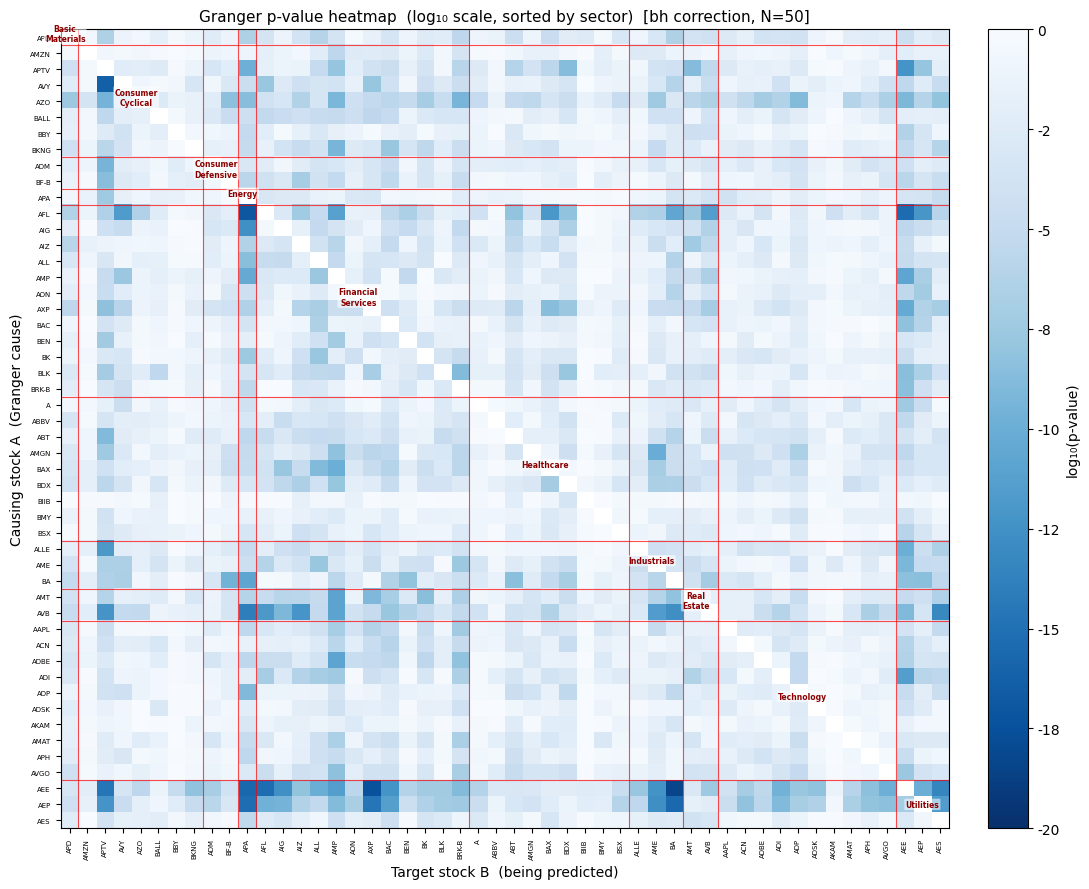

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Sort tickers by 2022 sector, then alphabetically within sector
sector_of = {t: sector_history.get(t, {}).get("2022", "Unknown") for t in tickers}
sorted_tickers = sorted(tickers, key=lambda t: (sector_of[t], t))
sorted_idx = [tickers.index(t) for t in sorted_tickers]

# Reorder p-value matrix: rows = cause, cols = target, both sorted by sector
pval_sorted = pval_df.iloc[sorted_idx, sorted_idx].values  # (N, N)
log_pval = np.log10(np.clip(pval_sorted, 1e-20, 1.0))     # clamp to avoid -inf

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(log_pval, cmap="Blues_r", aspect="auto", vmin=-20, vmax=0)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("log₁₀(p-value)", fontsize=10)
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

# Tick labels — show ticker symbols, rotated
ax.set_xticks(range(len(sorted_tickers)))
ax.set_yticks(range(len(sorted_tickers)))
ax.set_xticklabels(sorted_tickers, rotation=90, fontsize=5)
ax.set_yticklabels(sorted_tickers, fontsize=5)
ax.set_xlabel("Target stock B  (being predicted)", fontsize=10)
ax.set_ylabel("Causing stock A  (Granger cause)", fontsize=10)

# Draw sector boundary lines
sector_labels_sorted = [sector_of[t] for t in sorted_tickers]
boundaries = []
for i in range(1, len(sector_labels_sorted)):
    if sector_labels_sorted[i] != sector_labels_sorted[i - 1]:
        boundaries.append(i - 0.5)

for b in boundaries:
    ax.axhline(b, color="red", linewidth=0.8, alpha=0.7)
    ax.axvline(b, color="red", linewidth=0.8, alpha=0.7)

# Sector name annotations along the diagonal
prev = 0
for b in boundaries + [len(sorted_tickers)]:
    mid = (prev + b - 1) / 2
    sector_name = sector_labels_sorted[prev]
    ax.text(mid, mid, sector_name.replace(" ", "\n"),
            ha="center", va="center", fontsize=5.5,
            color="darkred", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.55, ec="none"))
    prev = int(b + 0.5)

ax.set_title(
    f"Granger p-value heatmap  (log₁₀ scale, sorted by sector)  "
    f"[{correction_used} correction, N={len(tickers)}]",
    fontsize=11
)
plt.tight_layout()
plt.show()

### Top stocks by in/out-degree

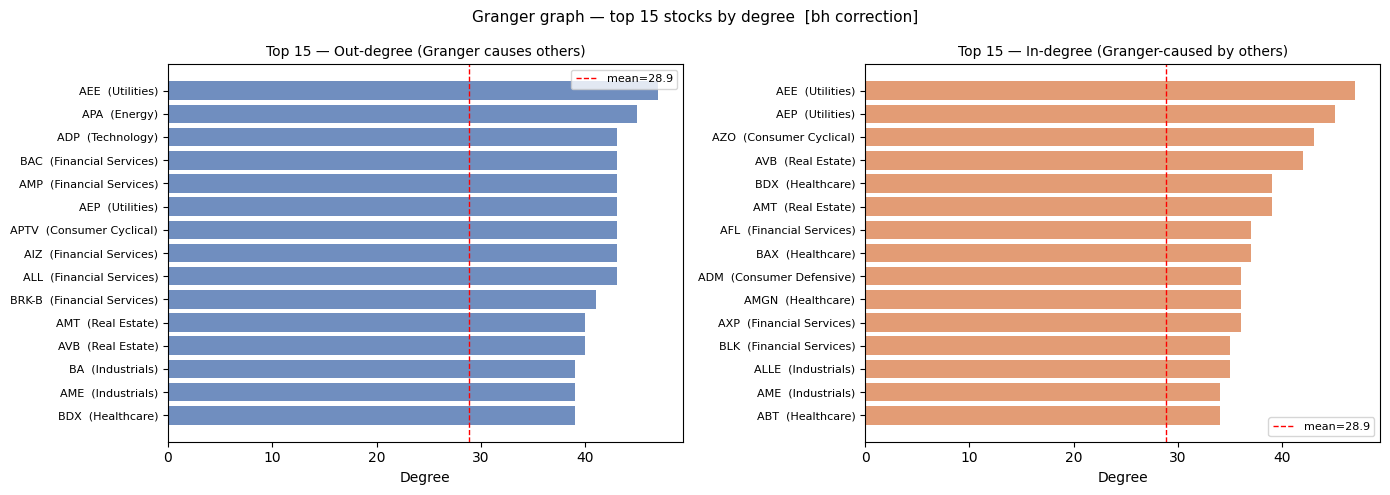

In [14]:
import matplotlib.pyplot as plt
import numpy as np

_TOP_K = 15

top_out_idx = np.argsort(out_degree)[::-1][:_TOP_K]
top_in_idx  = np.argsort(in_degree)[::-1][:_TOP_K]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, idx, degree, label, color in zip(
    axes,
    [top_out_idx, top_in_idx],
    [out_degree, in_degree],
    ["Out-degree (Granger causes others)", "In-degree (Granger-caused by others)"],
    ["#4c72b0", "#dd8452"],
):
    names  = [tickers[i] for i in idx]
    values = [degree[i] for i in idx]
    sectors_bar = [sector_of.get(t, "?") for t in names]

    bars = ax.barh(range(_TOP_K), values[::-1], color=color, alpha=0.8)
    ax.set_yticks(range(_TOP_K))
    ax.set_yticklabels(
        [f"{t}  ({s})" for t, s in zip(names[::-1], sectors_bar[::-1])],
        fontsize=8
    )
    ax.set_xlabel("Degree", fontsize=10)
    ax.set_title(f"Top {_TOP_K} — {label}", fontsize=10)
    ax.axvline(degree.mean(), color="red", linestyle="--", linewidth=1,
               label=f"mean={degree.mean():.1f}")
    ax.legend(fontsize=8)

plt.suptitle(
    f"Granger graph — top {_TOP_K} stocks by degree  [{correction_used} correction]",
    fontsize=11
)
plt.tight_layout()
plt.show()

## SAGEConv Directionality Verification

Confirms that `SAGEConv(flow="source_to_target")` produces different outputs when edge directions are reversed. This is a prerequisite for GNN-Granger training: if outputs are identical under edge reversal, SAGEConv is symmetrizing the adjacency internally and the directed Granger graph would be treated as undirected.

Test graph: 10 nodes, 12 asymmetric directed edges (chain 0→1→…→9 plus skip connections). No edge goes both ways. Same node features, same weights — only the edge direction changes between the two forward passes.

In [15]:
result = verify_sageconv_directionality()

print(f"flow direction : {result['flow']}")
print(f"test graph     : {result['num_nodes']} nodes, {result['num_edges']} directed edges")
print(f"max |out_fwd - out_rev| : {result['max_abs_diff']:.6f}")
print()
if result["passed"]:
    print("PASSED — SAGEConv respects edge direction.")
    print("GNN-Granger training may proceed with directed Granger edge_index.")
else:
    print("FAILED — SAGEConv is symmetrizing edges. Investigate before training.")

flow direction : source_to_target
test graph     : 10 nodes, 12 directed edges
max |out_fwd - out_rev| : 2.035303

PASSED — SAGEConv respects edge direction.
GNN-Granger training may proceed with directed Granger edge_index.


## Graph Statistics and Visualization

In [16]:
import importlib, src.graphs as _g; importlib.reload(_g)
from src.graphs import compute_graph_stats
import pandas as pd

N = len(tickers)
_DATE_YEARS = {"calm": 2017, "covid": 2020, "recent": 2023}

rows = []

# Correlation — dynamic, one row per sample date
for label, date_str in config.CORR_SAMPLE_DATES.items():
    s = compute_graph_stats(corr_samples[label], N, directed=False)
    rows.append({
        "Graph":       "Correlation",
        "Period":      f"{label} ({date_str})",
        "Nodes":       s["num_nodes"],
        "Edges":       s["num_edges"],
        "Density":     f"{s['density']:.4f}",
        "Mean Degree": f"{s['mean_degree']:.1f}",
        "Max Degree":  s["max_degree"],
    })

# Sector — annual, one row per year
for label, year in _DATE_YEARS.items():
    s = compute_graph_stats(sector_graphs[year], N, directed=False)
    rows.append({
        "Graph":       "Sector",
        "Period":      f"{label} ({year})",
        "Nodes":       s["num_nodes"],
        "Edges":       s["num_edges"],
        "Density":     f"{s['density']:.4f}",
        "Mean Degree": f"{s['mean_degree']:.1f}",
        "Max Degree":  s["max_degree"],
    })

# Granger — static, one row
s = compute_graph_stats(granger_edge_index, N, directed=True)
rows.append({
    "Graph":       f"Granger [{correction_used}]",
    "Period":      "static (train 2015-2022)",
    "Nodes":       s["num_nodes"],
    "Edges":       s["num_edges"],
    "Density":     f"{s['density']:.4f}",
    "Mean Degree": f"out={s['mean_out_degree']:.1f} / in={s['mean_in_degree']:.1f}",
    "Max Degree":  f"out={s['max_out_degree']} / in={s['max_in_degree']}",
})

df_stats = pd.DataFrame(rows)
print(df_stats.to_string(index=False))

       Graph                   Period  Nodes  Edges Density        Mean Degree     Max Degree
 Correlation        calm (2017-06-30)     50     46  0.0376                1.8              9
 Correlation       covid (2020-03-13)     50    862  0.7037               34.5             47
 Correlation      recent (2023-06-30)     50    394  0.3216               15.8             40
      Sector              calm (2017)     50    176  0.1437                7.0             11
      Sector             covid (2020)     50    176  0.1437                7.0             11
      Sector            recent (2023)     50    176  0.1437                7.0             11
Granger [bh] static (train 2015-2022)     50   1443  0.5890 out=28.9 / in=28.9 out=47 / in=47


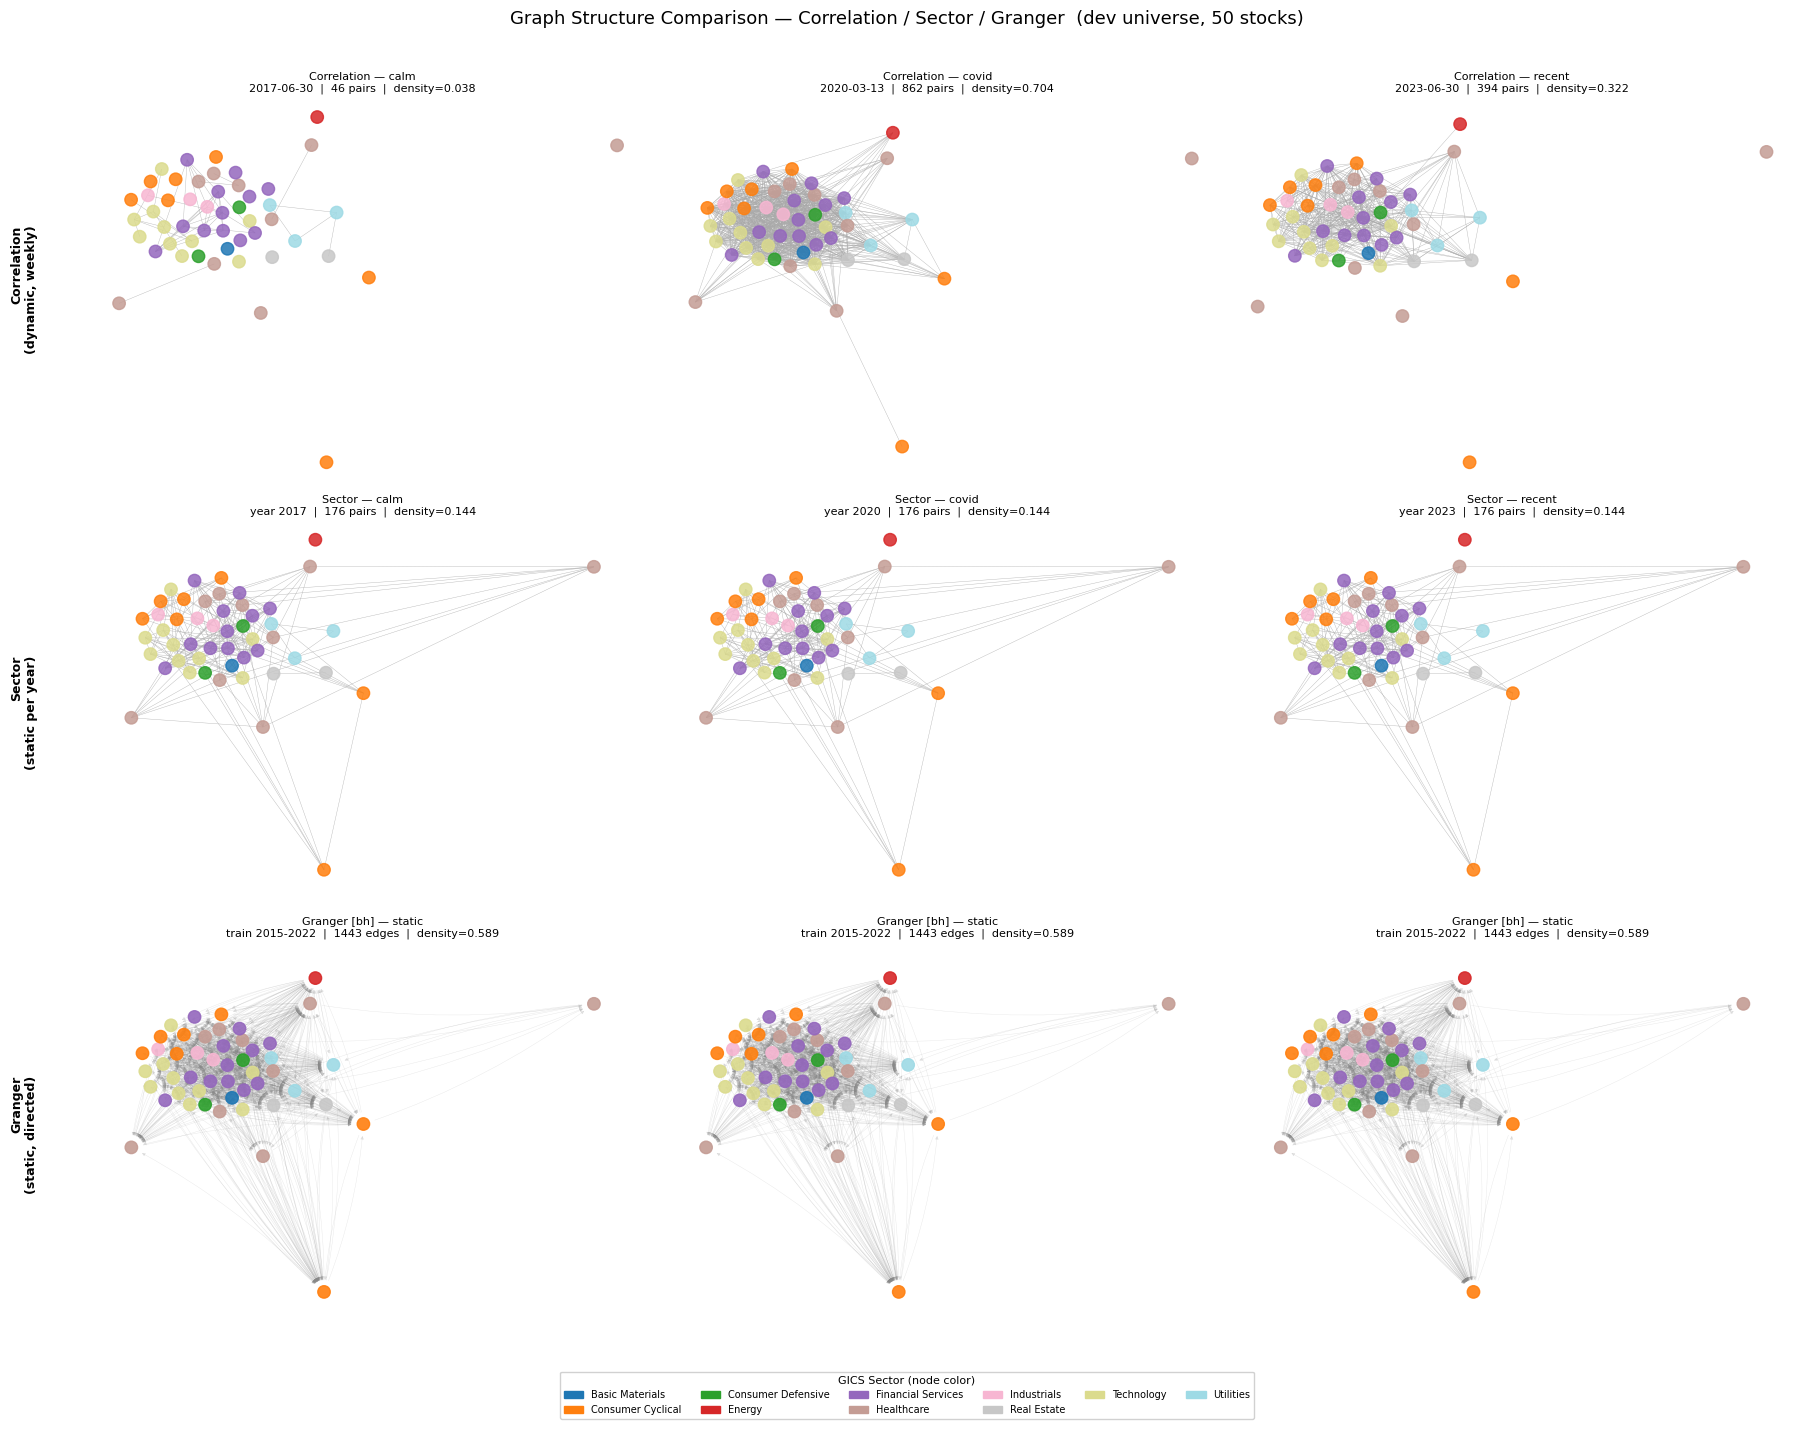

Saved -> C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\figures\graph_comparison.png


In [17]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs(config.FIGURES_DIR, exist_ok=True)

N = len(tickers)
_DATE_YEARS = {"calm": 2017, "covid": 2020, "recent": 2023}

# Compute shared node positions from the COVID correlation graph (densest graph).
# Using a fixed graph for position fitting means all 9 panels share the same layout,
# making cross-panel comparisons visually direct.
G_pos = nx.Graph()
G_pos.add_nodes_from(range(N))
ei_covid = corr_samples["covid"]
G_pos.add_edges_from(
    {(min(s, d), max(s, d)) for s, d in zip(ei_covid[0].tolist(), ei_covid[1].tolist())}
)
pos = nx.spring_layout(G_pos, seed=config.RANDOM_SEED, k=0.6)

# Build a single color map covering all sector labels across all years used
all_sectors = sorted({
    sector_history.get(t, {}).get(str(yr), "Unknown")
    for yr in list(_DATE_YEARS.values()) + [2022]
    for t in tickers
} - {"Unknown"})
color_map = {s: plt.cm.tab20(i / max(len(all_sectors) - 1, 1)) for i, s in enumerate(all_sectors)}
color_map["Unknown"] = (0.7, 0.7, 0.7, 1.0)

def _node_colors(year):
    return [
        color_map.get(sector_history.get(t, {}).get(str(year), "Unknown"), (0.7, 0.7, 0.7, 1.0))
        for t in tickers
    ]

date_items = list(config.CORR_SAMPLE_DATES.items())
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for col, (label, date_str) in enumerate(date_items):
    year = _DATE_YEARS[label]

    # ── Row 0: Correlation ────────────────────────────────────────────────────
    ax = axes[0, col]
    ei = corr_samples[label]
    G = nx.Graph()
    G.add_nodes_from(range(N))
    G.add_edges_from(
        {(min(s, d), max(s, d)) for s, d in zip(ei[0].tolist(), ei[1].tolist())}
    )
    nx.draw_networkx(G, pos=pos, ax=ax, node_color=_node_colors(year),
                     node_size=80, with_labels=False,
                     edge_color="#aaaaaa", width=0.3, alpha=0.85)
    n_pairs = ei.shape[1] // 2
    ax.set_title(
        f"Correlation — {label}\n{date_str}  |  {n_pairs} pairs  |  density={n_pairs/(N*(N-1)//2):.3f}",
        fontsize=8
    )
    ax.axis("off")

    # ── Row 1: Sector ─────────────────────────────────────────────────────────
    ax = axes[1, col]
    ei = sector_graphs[year]
    G = nx.Graph()
    G.add_nodes_from(range(N))
    G.add_edges_from(
        {(min(s, d), max(s, d)) for s, d in zip(ei[0].tolist(), ei[1].tolist())}
    )
    nx.draw_networkx(G, pos=pos, ax=ax, node_color=_node_colors(year),
                     node_size=80, with_labels=False,
                     edge_color="#aaaaaa", width=0.3, alpha=0.85)
    n_pairs = ei.shape[1] // 2
    ax.set_title(
        f"Sector — {label}\nyear {year}  |  {n_pairs} pairs  |  density={n_pairs/(N*(N-1)//2):.3f}",
        fontsize=8
    )
    ax.axis("off")

    # ── Row 2: Granger (static — identical panel for all three columns) ───────
    ax = axes[2, col]
    G = nx.DiGraph()
    G.add_nodes_from(range(N))
    G.add_edges_from(
        zip(granger_edge_index[0].tolist(), granger_edge_index[1].tolist())
    )
    # Node color from 2022 sector (end of training period)
    nx.draw_networkx_nodes(G, pos=pos, ax=ax, node_color=_node_colors(2022),
                           node_size=80, alpha=0.9)
    nx.draw_networkx_edges(G, pos=pos, ax=ax,
                           edge_color="#888888", alpha=0.2, width=0.3,
                           arrows=True, arrowsize=5,
                           connectionstyle="arc3,rad=0.08")
    n_edges = granger_edge_index.shape[1]
    ax.set_title(
        f"Granger [{correction_used}] — static\ntrain 2015-2022  |  {n_edges} edges  |  density={n_edges/(N*(N-1)):.3f}",
        fontsize=8
    )
    ax.axis("off")

# Row labels (outside left edge of each row)
for row_idx, row_name in enumerate([
    "Correlation\n(dynamic, weekly)",
    "Sector\n(static per year)",
    f"Granger\n(static, directed)",
]):
    axes[row_idx, 0].text(
        -0.08, 0.5, row_name,
        transform=axes[row_idx, 0].transAxes,
        fontsize=9, fontweight="bold", va="center", ha="right", rotation=90,
    )

# Shared sector legend below the figure
legend_handles = [mpatches.Patch(color=color_map[s], label=s) for s in all_sectors]
fig.legend(
    handles=legend_handles, fontsize=7, loc="lower center",
    ncol=min(len(all_sectors), 6), framealpha=0.9,
    title="GICS Sector (node color)", title_fontsize=8,
    bbox_to_anchor=(0.5, 0.0),
)

plt.suptitle(
    f"Graph Structure Comparison — Correlation / Sector / Granger  (dev universe, {N} stocks)",
    fontsize=13, y=1.01,
)
plt.tight_layout(rect=[0, 0.06, 1, 1])

out_path = os.path.join(config.FIGURES_DIR, "graph_comparison.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_path}")

In [18]:
import importlib, src.graphs as _g; importlib.reload(_g)
from src.graphs import make_pyg_data
import torch

N = len(tickers)
num_features = 10  # arbitrary dimension for shape testing
dummy_x = torch.randn(N, num_features)
dummy_y = torch.randn(N)

checks = [
    ("Correlation (calm)",   corr_samples["calm"],   False),
    ("Correlation (covid)",  corr_samples["covid"],  False),
    ("Correlation (recent)", corr_samples["recent"], False),
    ("Sector (2017)",        sector_graphs[2017],    False),
    ("Sector (2020)",        sector_graphs[2020],    False),
    ("Sector (2023)",        sector_graphs[2023],    False),
    ("Granger (directed)",   granger_edge_index,     True),
]

for name, ei, directed in checks:
    data = make_pyg_data(dummy_x, ei, dummy_y)
    assert data.x.shape == (N, num_features)
    assert data.y.shape == (N,)
    assert data.edge_index.shape[0] == 2
    if ei.shape[1] > 0:
        assert int(data.edge_index.max()) < N
    print(f"  {name:28s}  edge_index={tuple(data.edge_index.shape)}")

print(f"\nAll {len(checks)} PyG Data objects constructed and verified.")

  Correlation (calm)            edge_index=(2, 92)
  Correlation (covid)           edge_index=(2, 1724)
  Correlation (recent)          edge_index=(2, 788)
  Sector (2017)                 edge_index=(2, 352)
  Sector (2020)                 edge_index=(2, 352)
  Sector (2023)                 edge_index=(2, 352)
  Granger (directed)            edge_index=(2, 1443)

All 7 PyG Data objects constructed and verified.
